# 🏦 Loan Approval Prediction — Full ML Pipeline

> **Run in Google Colab.**  
> Secrets (`MONGO_DB_URL`, `MLFLOW_TRACKING_URI`, `MLFLOW_TRACKING_USERNAME`, `MLFLOW_TRACKING_PASSWORD`) must be saved in **Colab → Secrets**.  
> Upload `loan_approval_dataset.csv` when prompted (or place it in the Colab working directory).

## ⚙️ Phase 0 — Environment Setup

Install dependencies, set environment variables from Colab Secrets, and verify all connections.

In [1]:
# ── Install required packages ────────────────────────────────────────────────
# pymongo  : MongoDB client for data ingestion
# mlflow   : experiment tracking
# dagshub  : DagsHub MLflow integration helper
!pip install pymongo mlflow dagshub --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 903.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/2

In [2]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ──────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ set False to log locally inside Colab

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside Colab (no DagsHub needed)
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


In [3]:
# ── Verify MLflow connection ───────────────────────────────────────────────────
import mlflow

mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
print("MLflow tracking URI :", mlflow.get_tracking_uri())
print("✅ MLflow ready.")

MLflow tracking URI : https://dagshub.com/prithusarkar90/networksecurity.mlflow
✅ MLflow ready.


In [4]:
# ── Verify MongoDB connection ──────────────────────────────────────────────────
from pymongo import MongoClient

mongo_client = MongoClient(os.environ['MONGO_DB_URL'])
print("MongoDB server info:", mongo_client.server_info()['version'])
print("✅ MongoDB connected.")

MongoDB server info: 8.0.20
✅ MongoDB connected.


## 📥 Phase 1 — Data Ingestion

Upload the CSV → load into a pandas DataFrame → push raw records to MongoDB for persistence.

In [5]:
# ── Upload dataset from local machine ────────────────────────────────────────
# The file dialog will appear; select loan_approval_dataset.csv
from google.colab import files
uploaded = files.upload()    # triggers browser file-picker

Saving loan_approval_dataset.csv to loan_approval_dataset.csv


In [6]:
# ── Load CSV into pandas ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# The uploaded dict key is the original filename
csv_filename = list(uploaded.keys())[0]
df = pd.read_csv(csv_filename)

# Strip any accidental leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

✅ Dataset loaded: 4269 rows × 13 columns


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [7]:
# ── Push raw data to MongoDB ──────────────────────────────────────────────────
# Database : loan_db  |  Collection : raw_applications
db         = mongo_client["loan_db"]
collection = db["raw_applications"]

# Convert to list of dicts; replace NaN with None (JSON-safe)
records = df.where(pd.notnull(df), None).to_dict(orient="records")

# Drop old data on every run to avoid duplicates
collection.drop()
result = collection.insert_many(records)

print(f"✅ Inserted {len(result.inserted_ids)} documents into MongoDB → loan_db.raw_applications")

✅ Inserted 4269 documents into MongoDB → loan_db.raw_applications


## 🔍 Phase 2 — Exploratory Data Analysis (EDA)

Inspect shapes, dtypes, missing values, and class distributions before modelling.

In [8]:
# ── Basic shape & schema ─────────────────────────────────────────────────────
print("Shape :", df.shape)
print("\nColumn names :", df.columns.tolist())
print()
df.info()

Shape : (4269, 13)

Column names : ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value 

In [9]:
# ── Descriptive statistics ───────────────────────────────────────────────────
display(df.describe(include='all'))

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


Using target column: loan_status


,count
loan_status,
Approved,2656
Rejected,1613


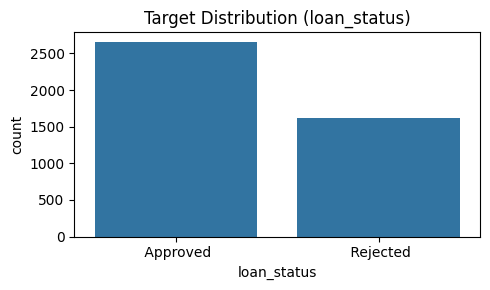

✅ EDA target distribution saved → eda_target_distribution.png


In [10]:
# ── Target column distribution ───────────────────────────────────────────────
target_col = 'loan_status'
print(f"Using target column: {target_col}")
display(df[target_col].value_counts(dropna=False))

plt.figure(figsize=(5, 3))
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution (loan_status)")
plt.tight_layout()
plt.savefig("eda_target_distribution.png", dpi=120)
plt.show()
print("✅ EDA target distribution saved → eda_target_distribution.png")

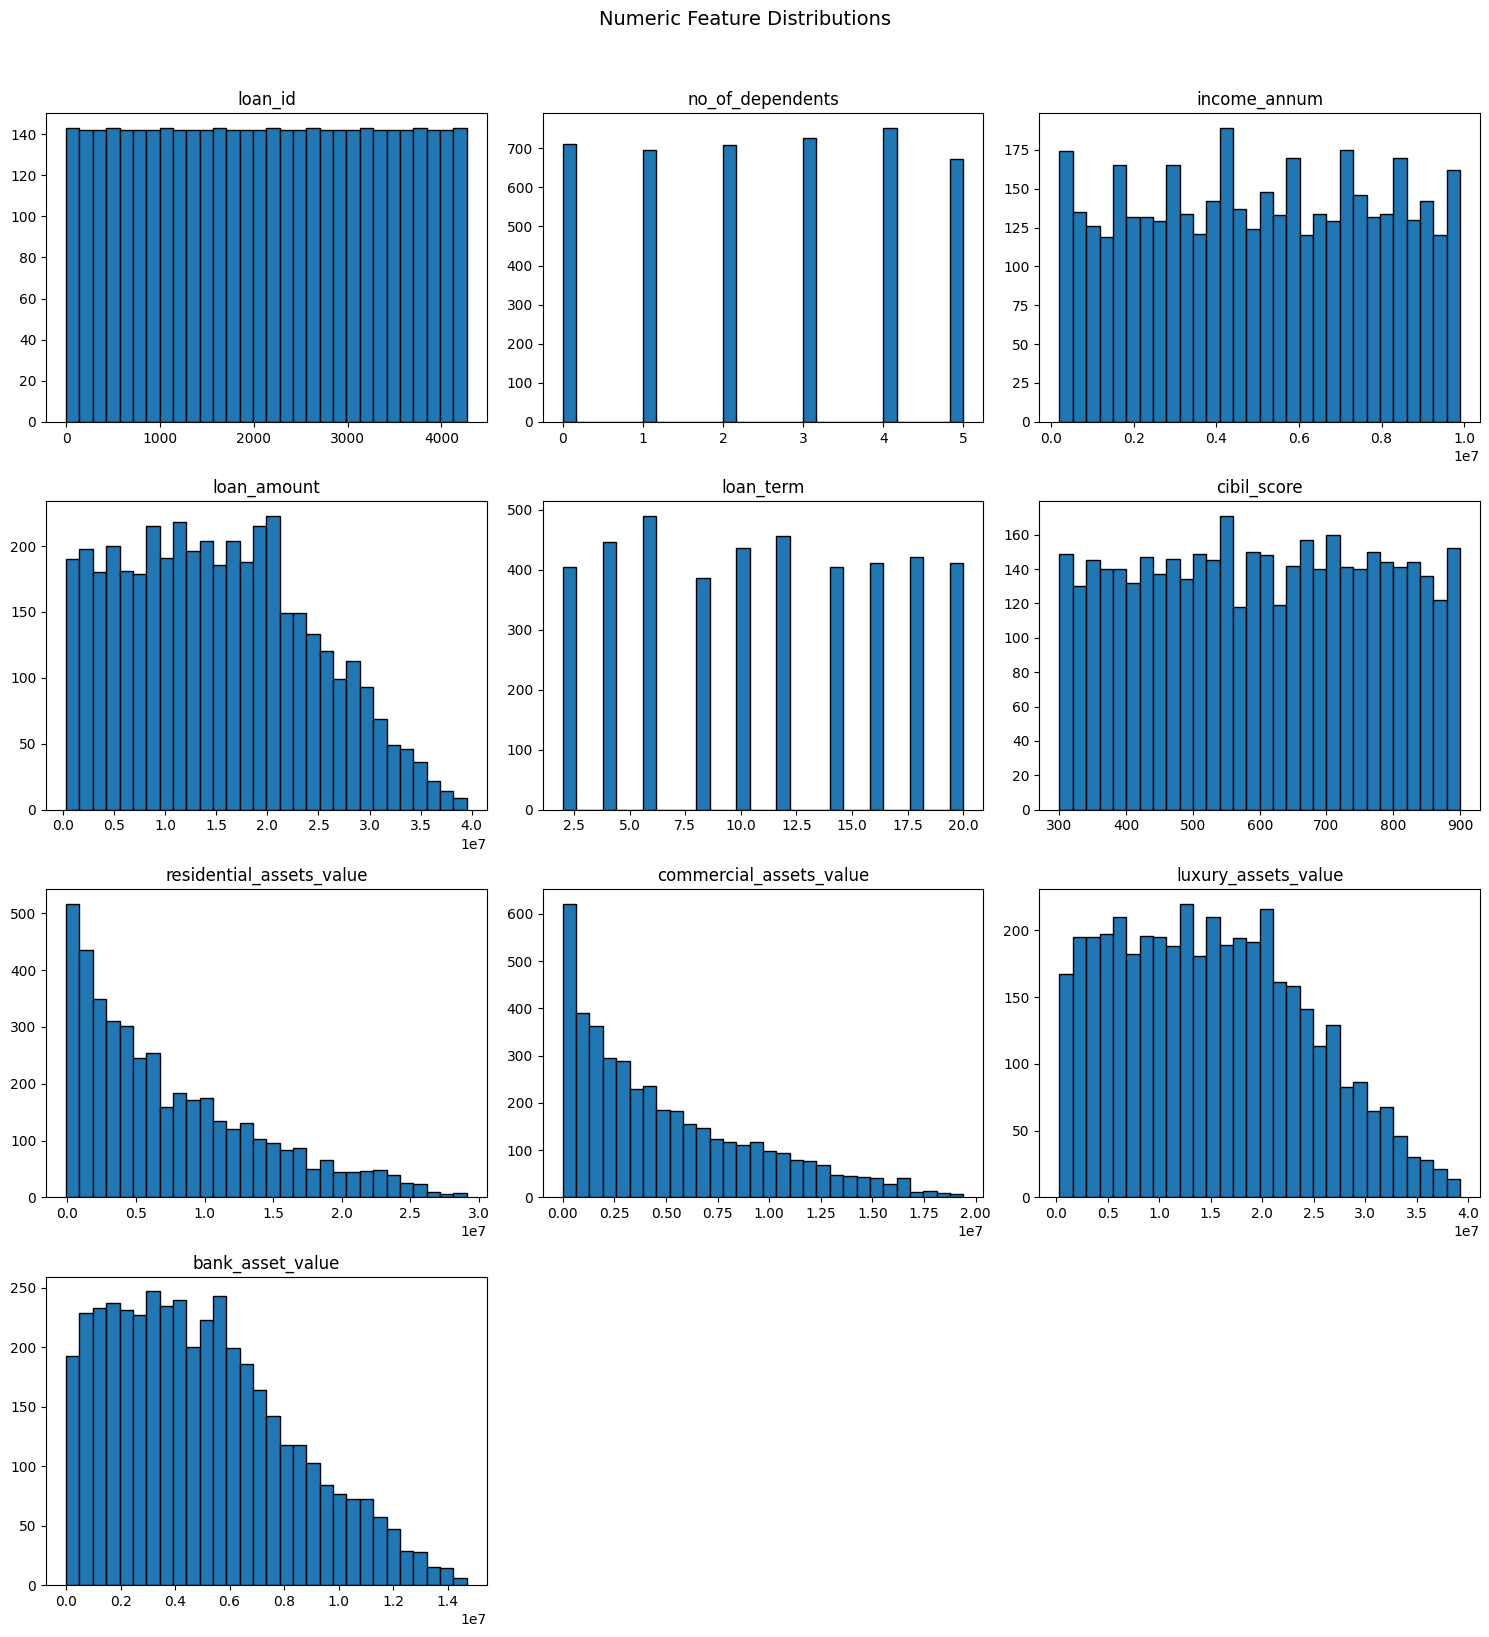

✅ EDA numeric distributions saved → eda_numeric_distributions.png


In [11]:
# ── Numeric feature distributions ────────────────────────────────────────────
num_preview = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(nrows=(len(num_preview) + 2) // 3, ncols=3,
                         figsize=(15, 4 * ((len(num_preview) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(num_preview):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("eda_numeric_distributions.png", dpi=120)
plt.show()
print("✅ EDA numeric distributions saved → eda_numeric_distributions.png")

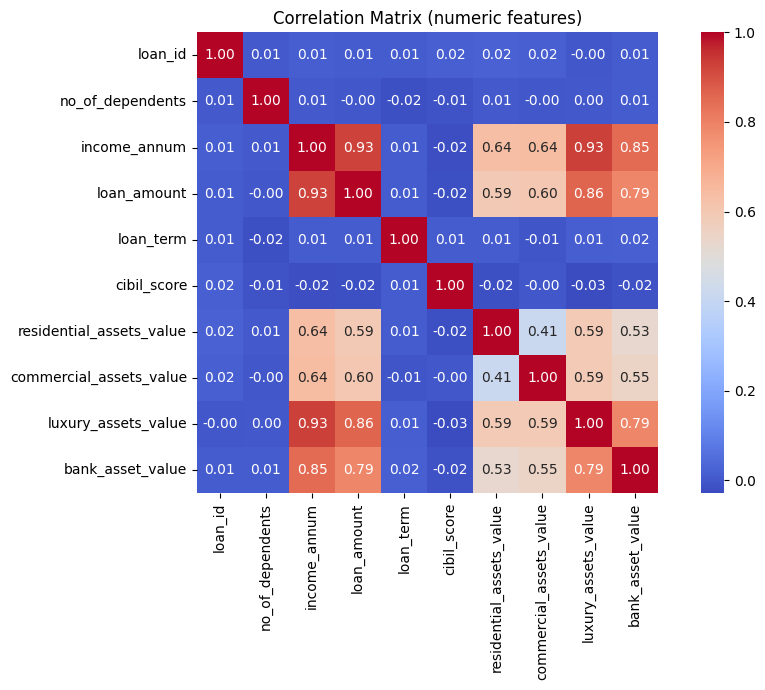

✅ EDA correlation heatmap saved → eda_correlation_heatmap.png


In [12]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Correlation Matrix (numeric features)")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=120)
plt.show()
print("✅ EDA correlation heatmap saved → eda_correlation_heatmap.png")

## 🛠️ Phase 3 — Feature Engineering & Preprocessing

Drop the ID column, encode the binary target, split into train/test sets, and build sklearn preprocessing pipelines for both Stage 1 (classification) and Stage 2 (regression).

In [13]:
# ── Drop non-predictive ID column ────────────────────────────────────────────
df = df.drop(columns=["loan_id"], errors="ignore")

# ── Prepare classification dataset ──────────────────────────────────────────
# Keep only rows where the target is not null
df_clf = df.dropna(subset=[target_col]).copy()

X = df_clf.drop(columns=[target_col])
y = df_clf[target_col].astype(str).str.strip().str.lower()

# Encode: 1 = Approved, 0 = Rejected
y = (y == 'approved').astype(int)

print("Feature matrix shape :", X.shape)
print("Target distribution   :\n", y.value_counts())

Feature matrix shape : (4269, 11)
Target distribution   :
 loan_status
1    2656
0    1613
Name: count, dtype: int64


In [14]:
# ── Identify column types ────────────────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns :", cat_cols)
print("Numerical columns   :", num_cols)

Categorical columns : ['education', 'self_employed']
Numerical columns   : ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [15]:
# ── Build shared sub-transformers ─────────────────────────────────────────────
# Numeric: fill missing with median → scale to zero mean, unit variance
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical: fill missing with mode → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

# ── Classification preprocessor (all features except target) ──────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

print("✅ Preprocessors built.")

✅ Preprocessors built.


In [16]:
# ── Train / test split for Stage 1 ──────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)
print("Train size :", X_train.shape)
print("Test size  :", X_test.shape)

Train size : (3415, 11)
Test size  : (854, 11)


## 🌲 Phase 4 — Stage 1: Loan Approval Classification

Train a Random Forest classifier (best params from prior GridSearchCV: `n_estimators=400`, `max_depth=None`, `max_features=None`).  
Log all metrics and the model artifact to MLflow/DagsHub.

In [17]:
# ── Imports ───────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)
import joblib

In [18]:
# ── Train Stage-1 RF classifier ──────────────────────────────────────────────
# Best hyper-params from GridSearchCV (see archived notebook)
rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_cls', RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        max_features=None,
        random_state=10,
        oob_score=True      # uses out-of-bag samples as a free validation set
    ))
])

rf_clf_pipeline.fit(X_train, y_train)
y_pred_cls = rf_clf_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_cls))
print("OOB score :", rf_clf_pipeline.named_steps['rf_cls'].oob_score_)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.98      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854

OOB score : 0.9841874084919473


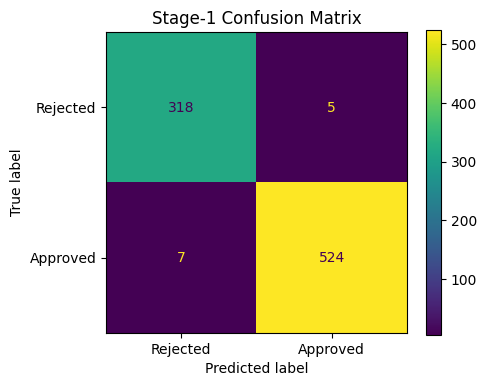

✅ Saved → stage1_confusion_matrix.png


In [19]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cls,
                                        display_labels=['Rejected','Approved'],
                                        ax=ax)
plt.title("Stage-1 Confusion Matrix")
plt.tight_layout()
plt.savefig("stage1_confusion_matrix.png", dpi=120)
plt.show()
print("✅ Saved → stage1_confusion_matrix.png")

Top 10 Important Features (Classification):
                       Feature  Importance
             num__cibil_score    0.827558
               num__loan_term    0.079926
             num__loan_amount    0.035917
            num__income_annum    0.021839
     num__luxury_assets_value    0.008104
num__residential_assets_value    0.007214
 num__commercial_assets_value    0.007041
        num__bank_asset_value    0.005609
        num__no_of_dependents    0.004388
       cat__self_employed_ No    0.000827


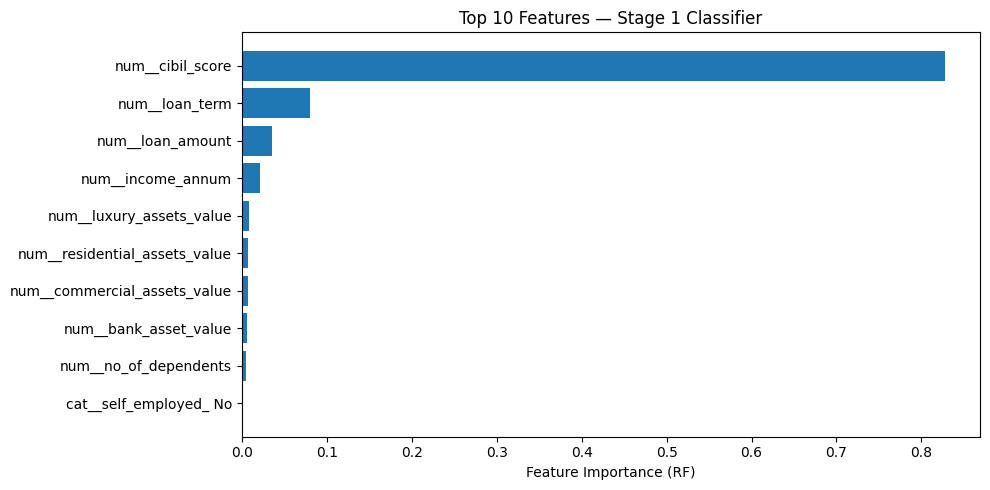

✅ Saved → stage1_feature_importance.png


In [20]:
# ── Feature importance — Stage 1 ─────────────────────────────────────────────
fi_clf = rf_clf_pipeline.named_steps['rf_cls'].feature_importances_
feat_names_clf = rf_clf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_clf_df = (pd.DataFrame({'Feature': feat_names_clf, 'Importance': fi_clf})
                       .sort_values('Importance', ascending=False))

print("Top 10 Important Features (Classification):\n", importance_clf_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(importance_clf_df['Feature'][:10][::-1],
         importance_clf_df['Importance'][:10][::-1])
plt.xlabel("Feature Importance (RF)")
plt.title("Top 10 Features — Stage 1 Classifier")
plt.tight_layout()
plt.savefig("stage1_feature_importance.png", dpi=120)
plt.show()
print("✅ Saved → stage1_feature_importance.png")

In [21]:
# ── Log Stage-1 run to MLflow ─────────────────────────────────────────────────
mlflow.set_experiment("loan_approval_stage1_classification")

clf_params = rf_clf_pipeline.named_steps['rf_cls'].get_params()

with mlflow.start_run(run_name="RF_Classifier_Stage1") as run:
    # Log hyper-parameters
    mlflow.log_params({
        "n_estimators":  clf_params['n_estimators'],
        "max_depth":     str(clf_params['max_depth']),
        "max_features":  str(clf_params['max_features']),
        "random_state":  clf_params['random_state'],
    })

    # Log evaluation metrics
    mlflow.log_metrics({
        "accuracy":  accuracy_score(y_test, y_pred_cls),
        "f1_score":  f1_score(y_test, y_pred_cls),
        "precision": precision_score(y_test, y_pred_cls),
        "recall":    recall_score(y_test, y_pred_cls),
        "oob_score": rf_clf_pipeline.named_steps['rf_cls'].oob_score_,
    })

    # Log plot artifacts
    mlflow.log_artifact("stage1_confusion_matrix.png")
    mlflow.log_artifact("stage1_feature_importance.png")

    # Save & log the pipeline model
    joblib.dump(rf_clf_pipeline, "stage_1_rf_classifier_pipeline.pkl")
    mlflow.log_artifact("stage_1_rf_classifier_pipeline.pkl")

    clf_run_id = run.info.run_id

print(f"✅ Stage-1 MLflow run logged. Run ID: {clf_run_id}")

2026/04/20 03:44:19 INFO mlflow.tracking.fluent: Experiment with name 'loan_approval_stage1_classification' does not exist. Creating a new experiment.


🏃 View run RF_Classifier_Stage1 at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/12/runs/70a03cf784af4d0fa8079de720faa718
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/12
✅ Stage-1 MLflow run logged. Run ID: 70a03cf784af4d0fa8079de720faa718


## 📈 Phase 5 — Stage 2: Loan Amount Regression

For **approved** applications only, predict the actual loan amount using a Random Forest regressor.  
Best params from prior GridSearchCV: `max_depth=8`, `max_features=None`, `min_samples_split=5`, `n_estimators=200`.

In [22]:
# ── Filter to approved rows only ─────────────────────────────────────────────
# The regression target only makes sense for approved applications
df["loan_status"] = df["loan_status"].str.strip()
approved_df = df[df["loan_status"] == "Approved"].copy()

reg_target = "loan_amount"
reg_df     = approved_df.dropna(subset=[reg_target]).copy()

X_reg = reg_df.drop(columns=[reg_target])
y_reg = reg_df[reg_target]

print(f"Approved subset shape : {X_reg.shape}")
print(f"Loan amount range     : {y_reg.min():,} – {y_reg.max():,}")

Approved subset shape : (2656, 11)
Loan amount range     : 300,000 – 39,500,000


In [23]:
# ── Regression preprocessor (same design, separate instance) ──────────────────
# We rebuild so it fits only on the regression training split
cat_cols_reg = X_reg.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_reg = X_reg.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns (reg) :", cat_cols_reg)
print("Numerical columns   (reg) :", num_cols_reg)

reg_preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols_reg),
    ('cat', categorical_transformer, cat_cols_reg)
], remainder='drop')

Categorical columns (reg) : ['education', 'self_employed', 'loan_status']
Numerical columns   (reg) : ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [24]:
# ── Train / test split for Stage 2 ──────────────────────────────────────────
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=10
)
print("Train size :", Xr_train.shape)
print("Test size  :", Xr_test.shape)

Train size : (2124, 11)
Test size  : (532, 11)


In [25]:
# ── Train Stage-2 RF regressor ───────────────────────────────────────────────
# Best hyper-params from GridSearchCV (see archived notebook)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('rf_reg', RandomForestRegressor(
        max_depth=8,
        max_features=None,
        min_samples_split=5,
        n_estimators=200,
        random_state=10
    ))
])

rf_reg_pipeline.fit(Xr_train, yr_train)
yr_test_pred = rf_reg_pipeline.predict(Xr_test)

mse = mean_squared_error(yr_test, yr_test_pred)
mae = mean_absolute_error(yr_test, yr_test_pred)
r2  = r2_score(yr_test, yr_test_pred)

print(f"MSE : {mse:,.2f}")
print(f"MAE : {mae:,.2f}")
print(f"R²  : {r2:.4f}")

MSE : 11,195,455,918,354.13
MAE : 2,512,447.57
R²  : 0.8644


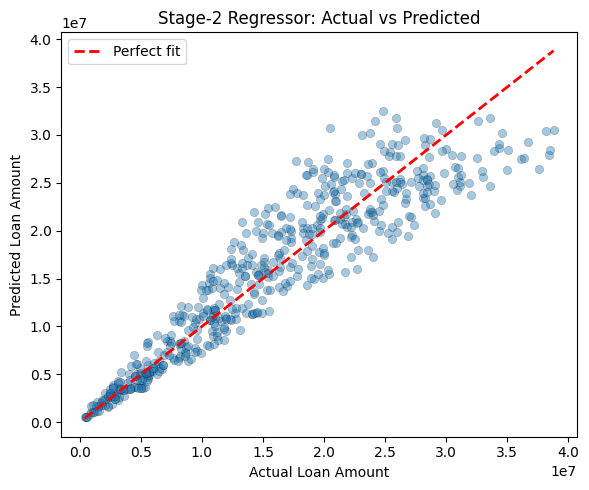

✅ Saved → stage2_actual_vs_predicted.png


In [26]:
# ── Actual vs Predicted scatter plot ─────────────────────────────────────────
plt.figure(figsize=(6, 5))
plt.scatter(yr_test, yr_test_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
plt.plot([yr_test.min(), yr_test.max()],
         [yr_test.min(), yr_test.max()], 'r--', lw=2, label='Perfect fit')
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Stage-2 Regressor: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.savefig("stage2_actual_vs_predicted.png", dpi=120)
plt.show()
print("✅ Saved → stage2_actual_vs_predicted.png")

Top 10 Important Features (Regression):
                       Feature  Importance
            num__income_annum    0.933516
             num__cibil_score    0.014345
     num__luxury_assets_value    0.011297
num__residential_assets_value    0.011170
 num__commercial_assets_value    0.009901
        num__bank_asset_value    0.008664
               num__loan_term    0.005687
        num__no_of_dependents    0.003711
       cat__self_employed_ No    0.000528
      cat__self_employed_ Yes    0.000436


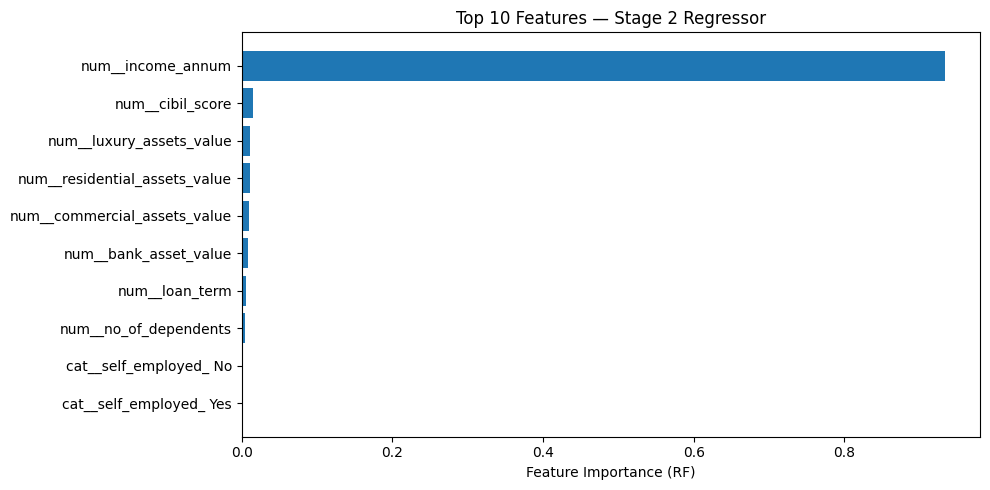

✅ Saved → stage2_feature_importance.png


In [27]:
# ── Feature importance — Stage 2 ─────────────────────────────────────────────
fi_reg = rf_reg_pipeline.named_steps['rf_reg'].feature_importances_
feat_names_reg = rf_reg_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_reg_df = (pd.DataFrame({'Feature': feat_names_reg, 'Importance': fi_reg})
                       .sort_values('Importance', ascending=False))

print("Top 10 Important Features (Regression):\n", importance_reg_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(importance_reg_df['Feature'][:10][::-1],
         importance_reg_df['Importance'][:10][::-1])
plt.xlabel("Feature Importance (RF)")
plt.title("Top 10 Features — Stage 2 Regressor")
plt.tight_layout()
plt.savefig("stage2_feature_importance.png", dpi=120)
plt.show()
print("✅ Saved → stage2_feature_importance.png")

In [28]:
# ── Log Stage-2 run to MLflow ─────────────────────────────────────────────────
mlflow.set_experiment("loan_approval_stage2_regression")

reg_params = rf_reg_pipeline.named_steps['rf_reg'].get_params()

with mlflow.start_run(run_name="RF_Regressor_Stage2") as run:
    # Log hyper-parameters
    mlflow.log_params({
        "n_estimators":       reg_params['n_estimators'],
        "max_depth":          str(reg_params['max_depth']),
        "max_features":       str(reg_params['max_features']),
        "min_samples_split":  reg_params['min_samples_split'],
        "random_state":       reg_params['random_state'],
    })

    # Log evaluation metrics
    mlflow.log_metrics({
        "mse": mse,
        "mae": mae,
        "r2":  r2,
    })

    # Log plot artifacts
    mlflow.log_artifact("stage2_actual_vs_predicted.png")
    mlflow.log_artifact("stage2_feature_importance.png")

    # Save & log the pipeline model
    joblib.dump(rf_reg_pipeline, "stage_2_rf_regression_pipeline.pkl")
    mlflow.log_artifact("stage_2_rf_regression_pipeline.pkl")

    reg_run_id = run.info.run_id

print(f"✅ Stage-2 MLflow run logged. Run ID: {reg_run_id}")

2026/04/20 03:45:08 INFO mlflow.tracking.fluent: Experiment with name 'loan_approval_stage2_regression' does not exist. Creating a new experiment.


🏃 View run RF_Regressor_Stage2 at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/13/runs/da1a4e9cf1af43838a20e4e64fbde445
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/13
✅ Stage-2 MLflow run logged. Run ID: da1a4e9cf1af43838a20e4e64fbde445


## 🔮 Phase 6 — Two-Stage Prediction Function

Load the saved pipelines and wire them into a single `two_stage_predict()` function:  
1. Classifier decides Approved / Rejected  
2. If Approved → Regressor predicts the sanctioned loan amount

In [29]:
# ── Load saved pipelines ─────────────────────────────────────────────────────
# (Already in memory; re-load from disk to confirm serialisation works)
clf = joblib.load("stage_1_rf_classifier_pipeline.pkl")
reg = joblib.load("stage_2_rf_regression_pipeline.pkl")

print("✅ Stage-1 classifier loaded. Expected features:", clf.feature_names_in_.tolist())
print("✅ Stage-2 regressor loaded.  Expected features:", reg.feature_names_in_.tolist())

✅ Stage-1 classifier loaded. Expected features: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
✅ Stage-2 regressor loaded.  Expected features: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [30]:
# ── Two-stage prediction function ────────────────────────────────────────────
def two_stage_predict(applicant_df: pd.DataFrame) -> dict:
    """
    Run a two-stage loan prediction.

    Stage 1 — Classification : Is the application Approved (1) or Rejected (0)?
    Stage 2 — Regression     : If approved, what loan amount should be sanctioned?

    Parameters
    ----------
    applicant_df : pd.DataFrame
        Single-row (or multi-row) DataFrame with the same feature columns
        used during training (excluding loan_id and loan_status).

    Returns
    -------
    dict with keys:
        'loan_status'           : int  (1 = Approved, 0 = Rejected)
        'approval_probability'  : float (probability of approval)
        'regression_prediction' : float | None  (predicted loan amount if approved)
    """
    result = {}

    # ── Stage 1: predict approval probability and class ───────────────────────
    approval_proba  = clf.predict_proba(applicant_df)[0]   # [P(rejected), P(approved)]
    approved        = clf.predict(applicant_df)[0]         # 0 or 1

    result['loan_status']          = int(approved)
    result['approval_probability'] = float(approval_proba[1])

    # ── Stage 2: predict loan amount only when approved ───────────────────────
    if approved == 1:
        # The regression model was trained on data that includes loan_status as
        # a feature (value = 'Approved' for all rows in its training set)
        reg_input = applicant_df.copy()
        reg_input['loan_status'] = 'Approved'
        result['regression_prediction'] = float(reg.predict(reg_input)[0])
    else:
        result['regression_prediction'] = None
        print("⚠️  Application Rejected — no loan amount predicted.")

    return result

In [31]:
# ── Quick smoke-test on a held-out test row ──────────────────────────────────
example_row = X_test.iloc[[0]]
print("Input features:")
display(example_row)

prediction = two_stage_predict(example_row)
print("\n📊 Prediction output:", prediction)

Input features:


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
3933,0,Not Graduate,No,9800000,20100000,16,606,6200000,800000,37300000,8700000



📊 Prediction output: {'loan_status': 1, 'approval_probability': 1.0, 'regression_prediction': 24661890.99107742}


In [32]:
# ── Test with a custom applicant profile ─────────────────────────────────────
sample = pd.DataFrame([{
    'no_of_dependents':        1,
    'education':               'Graduate',
    'self_employed':           'No',
    'income_annum':            1_200_000,
    'loan_amount':             30_000,
    'loan_term':               12,
    'cibil_score':             800,
    'residential_assets_value': 2_000_000,
    'commercial_assets_value': 2_000_000,
    'luxury_assets_value':     0,
    'bank_asset_value':        55_000,
}])

display(sample)
result = two_stage_predict(sample)
print("\n📊 Custom Applicant Prediction:", result)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,Graduate,No,1200000,30000,12,800,2000000,2000000,0,55000



📊 Custom Applicant Prediction: {'loan_status': 1, 'approval_probability': 0.8175, 'regression_prediction': 3052769.1915370994}


## 📦 Phase 7 — Save All Outputs & Zip

Collect every artifact generated during this run (plots, models, run IDs) into a single ZIP archive and download it.

In [33]:
# ── Persist MLflow run IDs for reference ─────────────────────────────────────
run_summary = {
    "stage1_clf_run_id": clf_run_id,
    "stage2_reg_run_id": reg_run_id,
    "mlflow_tracking_uri": os.environ['MLFLOW_TRACKING_URI'],
}

import json as _json
with open("mlflow_run_ids.json", "w") as f:
    _json.dump(run_summary, f, indent=2)

print("✅ Saved → mlflow_run_ids.json")
print(_json.dumps(run_summary, indent=2))

✅ Saved → mlflow_run_ids.json
{
  "stage1_clf_run_id": "70a03cf784af4d0fa8079de720faa718",
  "stage2_reg_run_id": "da1a4e9cf1af43838a20e4e64fbde445",
  "mlflow_tracking_uri": "https://dagshub.com/prithusarkar90/networksecurity.mlflow"
}


In [34]:
# ── Collect all output files ──────────────────────────────────────────────────
import zipfile, pathlib

OUTPUT_FILES = [
    # EDA plots
    "eda_target_distribution.png",
    "eda_numeric_distributions.png",
    "eda_correlation_heatmap.png",
    # Stage-1 artifacts
    "stage1_confusion_matrix.png",
    "stage1_feature_importance.png",
    "stage_1_rf_classifier_pipeline.pkl",
    # Stage-2 artifacts
    "stage2_actual_vs_predicted.png",
    "stage2_feature_importance.png",
    "stage_2_rf_regression_pipeline.pkl",
    # Metadata
    "mlflow_run_ids.json",
]

ZIP_NAME = "loan_approval_outputs.zip"

with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in OUTPUT_FILES:
        if pathlib.Path(fname).exists():
            zf.write(fname)
            print(f"  ✅ Added: {fname}")
        else:
            print(f"  ⚠️  Missing (skipped): {fname}")

print(f"\n📦 Archive created: {ZIP_NAME}")

  ✅ Added: eda_target_distribution.png
  ✅ Added: eda_numeric_distributions.png
  ✅ Added: eda_correlation_heatmap.png
  ✅ Added: stage1_confusion_matrix.png
  ✅ Added: stage1_feature_importance.png
  ✅ Added: stage_1_rf_classifier_pipeline.pkl
  ✅ Added: stage2_actual_vs_predicted.png
  ✅ Added: stage2_feature_importance.png
  ✅ Added: stage_2_rf_regression_pipeline.pkl
  ✅ Added: mlflow_run_ids.json

📦 Archive created: loan_approval_outputs.zip


In [35]:
# ── Download the ZIP to your local machine ───────────────────────────────────
from google.colab import files
files.download(ZIP_NAME)
print(f"✅ Download triggered for: {ZIP_NAME}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download triggered for: loan_approval_outputs.zip


---
## ✅ Pipeline Complete

| Phase | Description | Key outputs |
|-------|-------------|-------------|
| 0 | Environment setup | Env vars, MLflow & MongoDB verified |
| 1 | Data ingestion | DataFrame + MongoDB push |
| 2 | EDA | 3 × PNG plots |
| 3 | Feature engineering | Preprocessors, train/test splits |
| 4 | Stage-1 Classification | RF classifier + MLflow run |
| 5 | Stage-2 Regression | RF regressor + MLflow run |
| 6 | Prediction function | `two_stage_predict()` |
| 7 | Output packaging | `loan_approval_outputs.zip` |